# Phase 1 — Dataset Exploration & Preparation

**Dataset:** [tmnam20/ViMedAQA](https://huggingface.co/datasets/tmnam20/ViMedAQA) (ACL 2024)  
**Task:** Abstractive Question Answering — Vietnamese Medical Domain  

Mục tiêu của notebook này là:
1. Khám phá đặc trưng ngôn ngữ và cấu trúc của bộ dữ liệu y khoa tiếng Việt.
2. Làm sạch dữ liệu (loại bỏ trùng lặp, chuẩn hóa văn bản).
3. Thực hiện các phân tích nâng cao (Truncation, Abstractiveness) để chuẩn bị cho việc huấn luyện mô hình Seq2Seq.
4. Chia dữ liệu theo phương pháp Stratified và kiểm tra rò rỉ (Data Leakage).
---

## PHẦN 1: THIẾT LẬP MÔI TRƯỜNG (SET UP)
Trong phần này, chúng ta sẽ:
1. Cài đặt các thư viện cần thiết (`transformers`, `datasets`, `nltk`, `scikit-learn`).
2. Khai báo các đường dẫn thư mục chuẩn theo cấu trúc dự án.
3. Load Dataset 

### 1.1 Cài đặt thư viện cần thiết 

In [12]:
# Install required packages
# Skip if already installed in your environment
import subprocess, sys

packages = [
    "datasets==2.19.0", 
    "pandas==2.2.2", 
    "matplotlib==3.9.0", 
    "seaborn==0.13.2", 
    "scikit-learn",
    "transformers==4.40.0",
    "nltk==3.8.1"
]
for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

print("All packages installed.")

All packages installed.


###  1.2 Khai báo đường  dẫn & import thư viện 

In [44]:
import json
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from transformers import AutoTokenizer
import nltk
from tqdm import tqdm
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

nltk.download('punkt', quiet=True)

NOTEBOOK_DIR = os.path.dirname(os.path.abspath("__file__"))  
DATA_RAW       = os.path.join("..", "data", "raw")
DATA_PROCESSED = os.path.join("..", "data", "processed")
DATA_EDA       = os.path.join("..", "data", "eda")

os.makedirs(DATA_RAW,       exist_ok=True)
os.makedirs(DATA_PROCESSED, exist_ok=True)
os.makedirs(DATA_EDA,       exist_ok=True)

print("Paths configured:")
print(f"  Raw      : {os.path.abspath(DATA_RAW)}")
print(f"  Processed: {os.path.abspath(DATA_PROCESSED)}")
print(f"  EDA      : {os.path.abspath(DATA_EDA)}")

Paths configured:
  Raw      : d:\2025-2026 HKII\Học thống kê\Project\VietNamese_MediCal_Virtual_Assistant\data\raw
  Processed: d:\2025-2026 HKII\Học thống kê\Project\VietNamese_MediCal_Virtual_Assistant\data\processed
  EDA      : d:\2025-2026 HKII\Học thống kê\Project\VietNamese_MediCal_Virtual_Assistant\data\eda


## 1.3 Load Dataset from HuggingFace

In [14]:
# Load ViMedAQA from HuggingFace Hub
print("Loading tmnam20/ViMedAQA from HuggingFace Hub...")
dataset = load_dataset("tmnam20/ViMedAQA")

print("\nDataset info:")
print(dataset)
print("\nColumn names per split:")
for split in dataset:
    print(f"  {split}: {dataset[split].column_names}")

Loading tmnam20/ViMedAQA from HuggingFace Hub...

Dataset info:
DatasetDict({
    train: Dataset({
        features: ['question_idx', 'question', 'answer', 'context', 'title', 'keyword', 'topic', 'article_url', 'author', 'author_url'],
        num_rows: 39881
    })
    test: Dataset({
        features: ['question_idx', 'question', 'answer', 'context', 'title', 'keyword', 'topic', 'article_url', 'author', 'author_url'],
        num_rows: 2217
    })
    validation: Dataset({
        features: ['question_idx', 'question', 'answer', 'context', 'title', 'keyword', 'topic', 'article_url', 'author', 'author_url'],
        num_rows: 2215
    })
})

Column names per split:
  train: ['question_idx', 'question', 'answer', 'context', 'title', 'keyword', 'topic', 'article_url', 'author', 'author_url']
  test: ['question_idx', 'question', 'answer', 'context', 'title', 'keyword', 'topic', 'article_url', 'author', 'author_url']
  validation: ['question_idx', 'question', 'answer', 'context', 'title',

### Lưu vào thư mục dự án

In [15]:
# Merge all splits into one list, tag each sample with its original split
all_data = []
for split in dataset:
    for item in dataset[split]:
        record = dict(item)
        record["_original_split"] = split
        all_data.append(record)

raw_path = os.path.join(DATA_RAW, "vimedaq_full.json")
with open(raw_path, "w", encoding="utf-8") as f:
    json.dump(all_data, f, ensure_ascii=False, indent=2)

print(f"Raw data saved: {len(all_data)} total samples -> {os.path.abspath(raw_path)}")

Raw data saved: 44313 total samples -> d:\2025-2026 HKII\Học thống kê\Project\VietNamese_MediCal_Virtual_Assistant\data\raw\vimedaq_full.json


## PHẦN 2: LÀM SẠCH DỮ LIỆU (DATA CLEANING)

Mục tiêu của bước này là tạo ra một tập dữ liệu "vàng" (`df_clean`) bằng cách:
*   Loại bỏ các bản ghi trùng lặp (Exact & Near-duplicates).
*   Xử lý các giá trị rỗng (NaN) nếu có.
*   Chuẩn hóa định dạng văn bản (Normalization).


In [16]:
# Build a DataFrame for exploratory analysis
df = pd.DataFrame(all_data)
CORE_COLS = ["question", "context", "answer", "topic"]
df = df.dropna(subset=CORE_COLS).reset_index(drop=True)

# EDA-4: Exact Duplicate Detection
initial_count = len(df)
df = df.drop_duplicates(subset=['question', 'context']).reset_index(drop=True)
exact_dup_dropped = initial_count - len(df)

# Create a combined column for overall assessment
df['q_and_c'] = df['question'] + " " + df['context']

# Near-duplicate detection via TF-IDF on combined column
tfidf = TfidfVectorizer(max_features=5000)
tfidf_matrix = tfidf.fit_transform(df['q_and_c'])

# Memory-optimized chunked cosine similarity
CHUNK_SIZE = 1000
near_dup_indices = set()
n_samples = tfidf_matrix.shape[0]

print("Computing cosine similarity in chunks to prevent MemoryError...")
for i in range(0, n_samples, CHUNK_SIZE):
    end_i = min(i + CHUNK_SIZE, n_samples)
    
    # Calculate similarity for the current chunk against ALL other samples
    chunk_sim = cosine_similarity(tfidf_matrix[i:end_i], tfidf_matrix)
    
    # Mask out the lower triangle and diagonal to avoid self-matches and duplicate pairs
    # We only care about relationships where the column index > row index
    for row_idx_in_chunk, full_row_idx in enumerate(range(i, end_i)):
        # Only look at columns (other items) strictly AFTER the current item
        # to ensure we don't flag an item because of a reverse match we already processed
        matches = np.where(chunk_sim[row_idx_in_chunk, full_row_idx + 1:] > 0.95)[0]
        
        # Adjust matches index back to the global scale
        adjusted_matches = matches + (full_row_idx + 1)
        near_dup_indices.update(adjusted_matches)

# Convert set to sorted list for dropping
near_dup_indices_list = sorted(list(near_dup_indices))

# Drop near-duplicates and the temporary column
df_clean = df.drop(index=near_dup_indices_list).reset_index(drop=True)
df_clean = df_clean.drop(columns=['q_and_c'])

print(f"\nEDA: Duplication & Leakage Analysis")
print(f"  - Dropped exact duplicates: {exact_dup_dropped}")
print(f"  - Dropped near-duplicates (Q+C similarity > 0.95): {len(near_dup_indices_list)}")
print(f"  - Final clean samples: {len(df_clean)}")

# Word-level length statistics
df_clean["question_len"] = df_clean["question"].apply(lambda x: len(str(x).split()))
df_clean["context_len"]  = df_clean["context"].apply(lambda x: len(str(x).split()))
df_clean["answer_len"]   = df_clean["answer"].apply(lambda x: len(str(x).split()))

print("\nBasic length statistics (word count):")
print(df_clean[["question_len", "context_len", "answer_len"]].describe().round(2))

Computing cosine similarity in chunks to prevent MemoryError...

EDA: Duplication & Leakage Analysis
  - Dropped exact duplicates: 2
  - Dropped near-duplicates (Q+C similarity > 0.95): 20757
  - Final clean samples: 23554

Basic length statistics (word count):
       question_len  context_len  answer_len
count      23554.00     23554.00    23554.00
mean          13.86        95.31       23.19
std            5.05        78.83       13.35
min            3.00         0.00        1.00
25%           10.00        42.00       14.00
50%           13.00        71.00       21.00
75%           17.00       126.00       29.00
max           83.00      1197.00      204.00


---
## PHẦN 4: PHÂN TÍCH TỔNG THỂ (GLOBAL EDA)
Thực hiện các phân tích nâng cao trên toàn bộ tập dữ liệu sạch để xác định các tham số cấu hình cho giai đoạn Modelling.

## EDA 01: Phân tích rủi ro Truncation (Combined Input)

**Mục tiêu:** Tính toán độ dài token của chuỗi kết hợp `question + context`. Điều này cực kỳ quan trọng vì:
1. **ViT5-base** và **BARTpho-word** có giới hạn mặc định lần lượt là 512 và 1024 tokens.
2. Nếu tổng độ dài vượt quá giới hạn này, phần quan trọng nhất của `context` (thường nằm ở cuối) sẽ bị cắt bỏ, dẫn đến việc mô hình không thể tìm thấy câu trả lời.

Thống kê tỷ lệ vượt ngưỡng để quyết định tham số `max_source_length` khi huấn luyện.


In [17]:
# EDA-1: Tokenizer-specific Length Analysis
print("Loading Tokenizers for EDA-1...")
tok_vit5 = AutoTokenizer.from_pretrained("VietAI/vit5-base")
tok_bartpho = AutoTokenizer.from_pretrained("vinai/bartpho-word")

def truncation_stats(df, tokenizer, name):
    token_counts = []
    print(f"Đang phân tích {name}...")
    for _, row in tqdm(df.iterrows(), total=len(df)):
        # Format chuẩn mô hình: "question: {q} context: {c}"
        text = f"question: {str(row['question'])} context: {str(row['context'])}"
        n_tokens = len(tokenizer.encode(text))
        token_counts.append(n_tokens)
    
    df[f'input_{name}_tokens'] = token_counts
    total = len(token_counts)
    print(f"\n[Kết quả {name}]:")
    print(f"  - Max tokens: {max(token_counts)}")
    print(f"  - % Vượt 512:  {sum(1 for n in token_counts if n > 512) / total * 100:.2f}%")
    print(f"  - % Vượt 1024: {sum(1 for n in token_counts if n > 1024) / total * 100:.2f}%")
    return df

df_clean = truncation_stats(df_clean, tok_vit5, "vit5")
df_clean = truncation_stats(df_clean, tok_bartpho, "bartpho")


# EDA-2: Abstractiveness Measurement (N-gram overlap)
def calculate_overlap(context, answer):
    c_tokens = set(nltk.word_tokenize(str(context).lower()))
    a_tokens = set(nltk.word_tokenize(str(answer).lower()))
    if not a_tokens: return 0.0
    return len(c_tokens.intersection(a_tokens)) / len(a_tokens)

df_clean['extractive_overlap'] = df_clean.apply(lambda x: calculate_overlap(x['context'], x['answer']), axis=1)

print("\nEDA-2: Abstractiveness Measurement:")
print(f"  Average vocabulary overlap between Answer and Context: {df_clean['extractive_overlap'].mean()*100:.2f}%")
print(f"  (Overlap < 100% indicates abstractive paraphrasing/generation)")

Loading Tokenizers for EDA-1...


d:\2025-2026 HKII\Học thống kê\Project\VietNamese_MediCal_Virtual_Assistant\venv\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Đang phân tích vit5...


100%|██████████| 23554/23554 [00:19<00:00, 1229.80it/s]



[Kết quả vit5]:
  - Max tokens: 1549
  - % Vượt 512:  0.65%
  - % Vượt 1024: 0.03%
Đang phân tích bartpho...


100%|██████████| 23554/23554 [00:25<00:00, 933.83it/s] 



[Kết quả bartpho]:
  - Max tokens: 1549
  - % Vượt 512:  0.78%
  - % Vượt 1024: 0.03%

EDA-2: Abstractiveness Measurement:
  Average vocabulary overlap between Answer and Context: 82.24%
  (Overlap < 100% indicates abstractive paraphrasing/generation)


---
### Nhận xét kết quả phân tích 

Dựa trên số liệu thống kê từ 23,554 mẫu dữ liệu sau khi đã làm sạch (Deduplicated), chúng tôi rút ra các kết luận quan trọng cho giai đoạn huấn luyện mô hình:

##### 1. Cấu hình độ dài đầu vào (Input Truncation)
*   **Kết quả:** Cả hai tokenizer (ViT5 và BARTpho) đều cho thấy rủi ro mất mát thông tin ở ngưỡng 512 tokens là cực kỳ thấp (**< 1%**).
*   **Quyết định:** Thiết lập tham số `max_source_length = 512`. Điều này đảm bảo bao phủ được hơn 99% ngữ cảnh của bộ dữ liệu mà vẫn tối ưu hóa được bộ nhớ VRAM và tốc độ huấn luyện trên GPU T4.
*   **Điểm cá biệt:** Phát hiện mẫu có độ dài lên tới 1549 tokens (chiếm 0.03%). Các mẫu này sẽ bị cắt cụt trong quá trình huấn luyện, nhưng do tỷ lệ quá nhỏ nên không ảnh hưởng đến độ chính xác tổng thể của mô hình.

##### 2. Đặc trưng bài toán Abstractive QA
*   **Kết quả:** Độ tương đồng từ vựng (Vocabulary Overlap) trung bình giữa Câu trả lời và Ngữ cảnh đạt **82.24%**.
*   **Phân tích:** 
    *   Khoảng **17.76%** nội dung trong câu trả lời là các từ vựng mới, được diễn đạt lại (paraphrased) hoặc tổng hợp từ nhiều ý trong văn bản gốc.
    *   Chỉ số này khẳng định bộ dữ liệu **ViMedAQA** mang tính trừu tượng (Abstractive) rõ rệt, không phải là bài toán trích xuất (Extractive) đơn thuần.
*   **Định hướng:** Việc sử dụng các mô hình Transformer như ViT5 và BARTpho là hoàn toàn hợp lý vì chúng có khả năng sinh văn bản và hiểu ngữ cảnh sâu để tạo ra các câu trả lời tự nhiên.

##### 3. So sánh hiệu năng Tokenizer
*   **Quan sát:** BARTpho-word tạo ra số lượng token nhiều hơn ViT5 khoảng **20%** trên cùng một đơn vị văn bản (tỷ lệ vượt ngưỡng 512 là 0.78% so với 0.65% của ViT5).
*   **Lưu ý:** Cần chú ý điều chỉnh `per_device_train_batch_size` khi huấn luyện BARTpho để tránh lỗi hết bộ nhớ (Out of Memory) do đặc thù phân mảnh token của nó.



## EDA 02: Phân tích tính trừu tượng của câu trả lời (Abstractiveness Measurement)

**Mục tiêu:** Kiểm tra xem câu trả lời là dạng trích xuất nguyên bản (Extractive) hay được diễn đạt lại (Abstractive). 

Bài toán **Abstractive QA** đòi hỏi mô hình phải có khả năng tổng hợp và viết lại câu. Chúng ta sẽ đo lường điều này qua hai chỉ số:
1. **Vocabulary Overlap (1-gram):** Tỷ lệ từ vựng chung giữa Answer và Context. Chỉ số này càng thấp, tính diễn đạt lại càng cao.
2. **Novel N-grams (2-gram & 3-gram):** Tỷ lệ các cụm từ hoàn toàn mới xuất hiện trong câu trả lời. Đây là thước đo chuẩn để xác định mô hình cần "sáng tạo" cấu trúc câu đến mức nào.


In [40]:
def novel_ngram_ratio(answer, context, n=2):
    ans_ngrams = set(zip(*[answer.split()[i:] for i in range(n)]))
    ctx_ngrams = set(zip(*[context.split()[i:] for i in range(n)]))
    if not ans_ngrams:
        return 0.0
    novel = ans_ngrams - ctx_ngrams
    return len(novel) / len(ans_ngrams)

def get_top_ngrams(corpus, n=None, top_k=10):
    vec = CountVectorizer(ngram_range=(n, n)).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:top_k]


# tỷ lệ từ vựng chung giữa answer và context
df_clean['novel_bigram'] = df.apply(lambda r: novel_ngram_ratio(r['answer'], r['context'], 2), axis=1)
df_clean['novel_trigram'] = df.apply(lambda r: novel_ngram_ratio(r['answer'], r['context'], 3), axis=1)
print(f"Novel bigram mean: {df_clean['novel_bigram'].mean():.2%}")
print(f"Novel trigram mean: {df_clean['novel_trigram'].mean():.2%}")

# tỷ lệ các cụm từ mới xuất hiện 
print("EDA-3: Top 10 Question Start Bi-grams:")
top_question_bigrams = get_top_ngrams(df_clean['question'], n=2, top_k=10)
for word, freq in top_question_bigrams:
    print(f"  - '{word}': {freq}")

print("\nEDA-3: Top 10 Context Tri-grams:")
top_context_trigrams = get_top_ngrams(df_clean['context'], n=3, top_k=10)
for word, freq in top_context_trigrams:
    print(f"  - '{word}': {freq}")



Novel bigram mean: 41.05%
Novel trigram mean: 50.36%
EDA-3: Top 10 Question Start Bi-grams:
  - 'sử dụng': 3545
  - 'có thể': 3299
  - 'thế nào': 3149
  - 'như thế': 2590
  - 'là gì': 2567
  - 'tác dụng': 1980
  - 'điều trị': 1801
  - 'trường hợp': 1255
  - 'có tác': 1101
  - 'bao nhiêu': 1055

EDA-3: Top 10 Context Tri-grams:
  - 'các triệu chứng': 2227
  - 'có tác dụng': 2167
  - 'có thể gây': 1850
  - 'sử dụng thuốc': 1615
  - 'được sử dụng': 1421
  - 'khi sử dụng': 1366
  - 'cũng có thể': 1169
  - 'có thể làm': 1152
  - 'có thể được': 1053
  - 'tác dụng phụ': 1047


---
### Nhận xét về độ trừu tượng và đặc trưng ngôn ngữ 

##### 1. Độ trừu tượng thực tế (Novel N-grams)
*   **Chỉ số:** Novel Bigram đạt **39.64%** và Novel Trigram đạt **49.13%**.
*   **Nhận xét:** Đây là những con số cực kỳ ấn tượng cho một bộ dữ liệu Abstractive QA. 
    *   Việc có tới gần **40% cụm 2 từ** và **50% cụm 3 từ** trong câu trả lời là "hoàn toàn mới" so với ngữ cảnh chứng tỏ người soạn bộ dữ liệu đã thực hiện paraphrase (diễn đạt lại) rất mạnh tay.
    *   **Thách thức cho mô hình:** Mô hình không thể chỉ học cách "copy-paste" các cụm từ dài. Nó bắt buộc phải hiểu ngữ nghĩa để tự xây dựng lại cấu trúc câu mới. Điều này khẳng định việc chọn các kiến trúc như **ViT5** hay **BARTpho** sẽ được phát huy tối đa ở đây.

##### 2. Đặc trưng câu hỏi (Question Start Bi-grams)
*   **Quan sát:** Các cụm từ như *"sử dụng thế nào"*, *"như thế nào"*, *"là gì"*, *"tác dụng"* và *"điều trị"* chiếm đa số.
*   **Nhận xét:** 
    *   Bộ dữ liệu tập trung mạnh vào các câu hỏi **thực hành** (cách dùng thuốc, phương pháp điều trị) và **định nghĩa** (bệnh này là gì, thuốc kia là gì).
    *   Sự xuất hiện dày đặc của cụm từ *"có thể"* (3299 lần) cho thấy các câu hỏi y khoa thường mang tính tư vấn và dự báo rủi ro.

##### 3. Đặc trưng ngữ cảnh (Context Tri-grams)
*   **Quan sát:** Các cụm từ chuyên môn xuất hiện với tần suất cao như *"các triệu chứng"*, *"tác dụng phụ"*, *"sử dụng thuốc"*, *"có tác dụng"*.
*   **Nhận xét:** 
    *   Ngữ cảnh cung cấp thông tin rất bài bản về dược lý và bệnh học. 
    *   Các cụm từ này thường xuyên lặp lại, tạo nên một **"bộ khung" ngôn ngữ y khoa** ổn định. Mô hình sẽ dễ dàng học được các thực thể (Entities) này, nhưng thử thách nằm ở việc kết nối chúng lại để trả lời các câu hỏi phức tạp (Reasoning).

**Kết luận:** Dữ liệu có độ khó cao về mặt sinh văn bản (high novelty) nhưng lại có cấu trúc từ vựng miền (domain vocabulary) rất rõ ràng. Đây là điều kiện lý tưởng để fine-tune một mô hình QA chuyên biệt.

---


## EDA 03: Phân loại câu hỏi (Question Categorization)

**Mục tiêu:** Nhóm các câu hỏi vào các danh mục chức năng (Tại sao, Làm thế nào, Thuốc, Triệu chứng...). 
Việc phân loại này giúp:
1. **Hiểu phân phối bài toán:** Biết được mô hình sẽ phải giải quyết dạng câu hỏi nào nhiều nhất.
2. **Stratified Splitting:** Sử dụng nhãn này để chia tập Train/Test, đảm bảo tập Test không bị thiếu hụt bất kỳ dạng câu hỏi quan trọng nào.


In [19]:
def categorize_question(q):
    q_lower = str(q).lower()
    if any(w in q_lower for w in ["thuốc", "liều", "uống", "tác dụng phụ", "dược"]):
        return "MEDICATION"
    if any(w in q_lower for w in ["tại sao", "nguyên nhân", "vì sao", "do đâu"]):
        return "WHY"
    if any(w in q_lower for w in ["làm thế nào", "cách", "phương pháp", "quy trình"]):
        return "HOW"
    if any(w in q_lower for w in ["triệu chứng", "dấu hiệu", "biểu hiện", "phát hiện"]):
        return "SYMPTOM"
    if any(w in q_lower for w in ["chẩn đoán", "điều trị", "xét nghiệm", "khám"]):
        return "TREATMENT"
    if any(w in q_lower for w in ["là gì", "định nghĩa", "thế nào là", "là loại"]):
        return "DEFINITION"
    
    return "OTHER"

# Áp dụng phân loại
df_clean['question_type'] = df_clean['question'].apply(categorize_question)

print("\nEDA-4: Question Type Distribution:")
print(df_clean['question_type'].value_counts())
print("-" * 30)
print(df_clean['question_type'].value_counts(normalize=True).map('{:.2%}'.format))



EDA-4: Question Type Distribution:
question_type
OTHER         10524
MEDICATION     6609
DEFINITION     1503
TREATMENT      1428
HOW            1206
SYMPTOM        1189
WHY            1095
Name: count, dtype: int64
------------------------------
question_type
OTHER         44.68%
MEDICATION    28.06%
DEFINITION     6.38%
TREATMENT      6.06%
HOW            5.12%
SYMPTOM        5.05%
WHY            4.65%
Name: proportion, dtype: object


---
###  Nhận xét về phân phối loại câu hỏi 

Dựa trên kết quả phân loại quy tắc (Rule-based), chúng tôi nhận thấy các đặc điểm sau của bộ dữ liệu:

1. **Sự áp đảo của các câu hỏi về Dược phẩm (MEDICATION - 28.06%)**:
    *   Gần **1/3** bộ dữ liệu tập trung vào các chủ đề: *tên thuốc, liều dùng, cách uống và tác dụng phụ*.
    *   **Nhận định:** Mô hình sau khi huấn luyện (chatbot) sẽ có xu hướng trở thành một "chuyên gia về thuốc". Bộ dữ liệu ViMedAQA rất phù hợp trong việc hỗ trợ tư vấn sử dụng dược phẩm.

2. **Sự phân bổ đồng đều của các nhóm chuyên môn khác**:
    *   Các nhóm **DEFINITION** (6.38%), **TREATMENT** (6.06%), **HOW** (5.12%), **SYMPTOM** (5.05%) và **WHY** (4.65%) có tỷ lệ khá tương đồng.
    *   Mặc dù số lượng ít hơn nhóm Medication, nhưng sự hiện diện đầy đủ của các nhóm này đảm bảo tính đa dạng của bài toán QA y khoa (từ định nghĩa, triệu chứng đến phương pháp điều trị và giải thích nguyên nhân).

3. **Tỷ lệ nhóm OTHER còn cao (44.68%)**:
    *   Gần một nửa số câu hỏi không chứa các từ khóa đặc trưng mà chúng ta đã định nghĩa. Điều này cho thấy ngôn ngữ trong bộ dữ liệu rất phong phú và đa dạng về cách diễn đạt. 
    *   **Hành động:**  vẫn sẽ giữ nguyên nhóm này vì nó đại diện cho các câu hỏi tổng hợp hoặc đa mục tiêu.

**Kết luận cho giai đoạn Modelling:**
Sự mất cân bằng giữa nhóm `MEDICATION` và các nhóm còn lại là một điểm cần lưu ý. Khi thực hiện chia dữ liệu (Split), chúng ta **bắt buộc phải sử dụng nhãn này để Stratify**, nhằm đảm bảo tập Test có đủ các mẫu của nhóm thiểu số (như `WHY` hoặc `SYMPTOM`) để đánh giá khả năng suy luận của mô hình một cách chính xác nhất.

---


## PHẦN 5: TRỰC QUAN HÓA (VISUALIZATION)

Sử dụng biểu đồ để tổng hợp lại các phân phối quan trọng như: phân phối chủ đề (Topic), phân phối loại câu hỏi (Question Type) và phân phối độ dài văn bản.


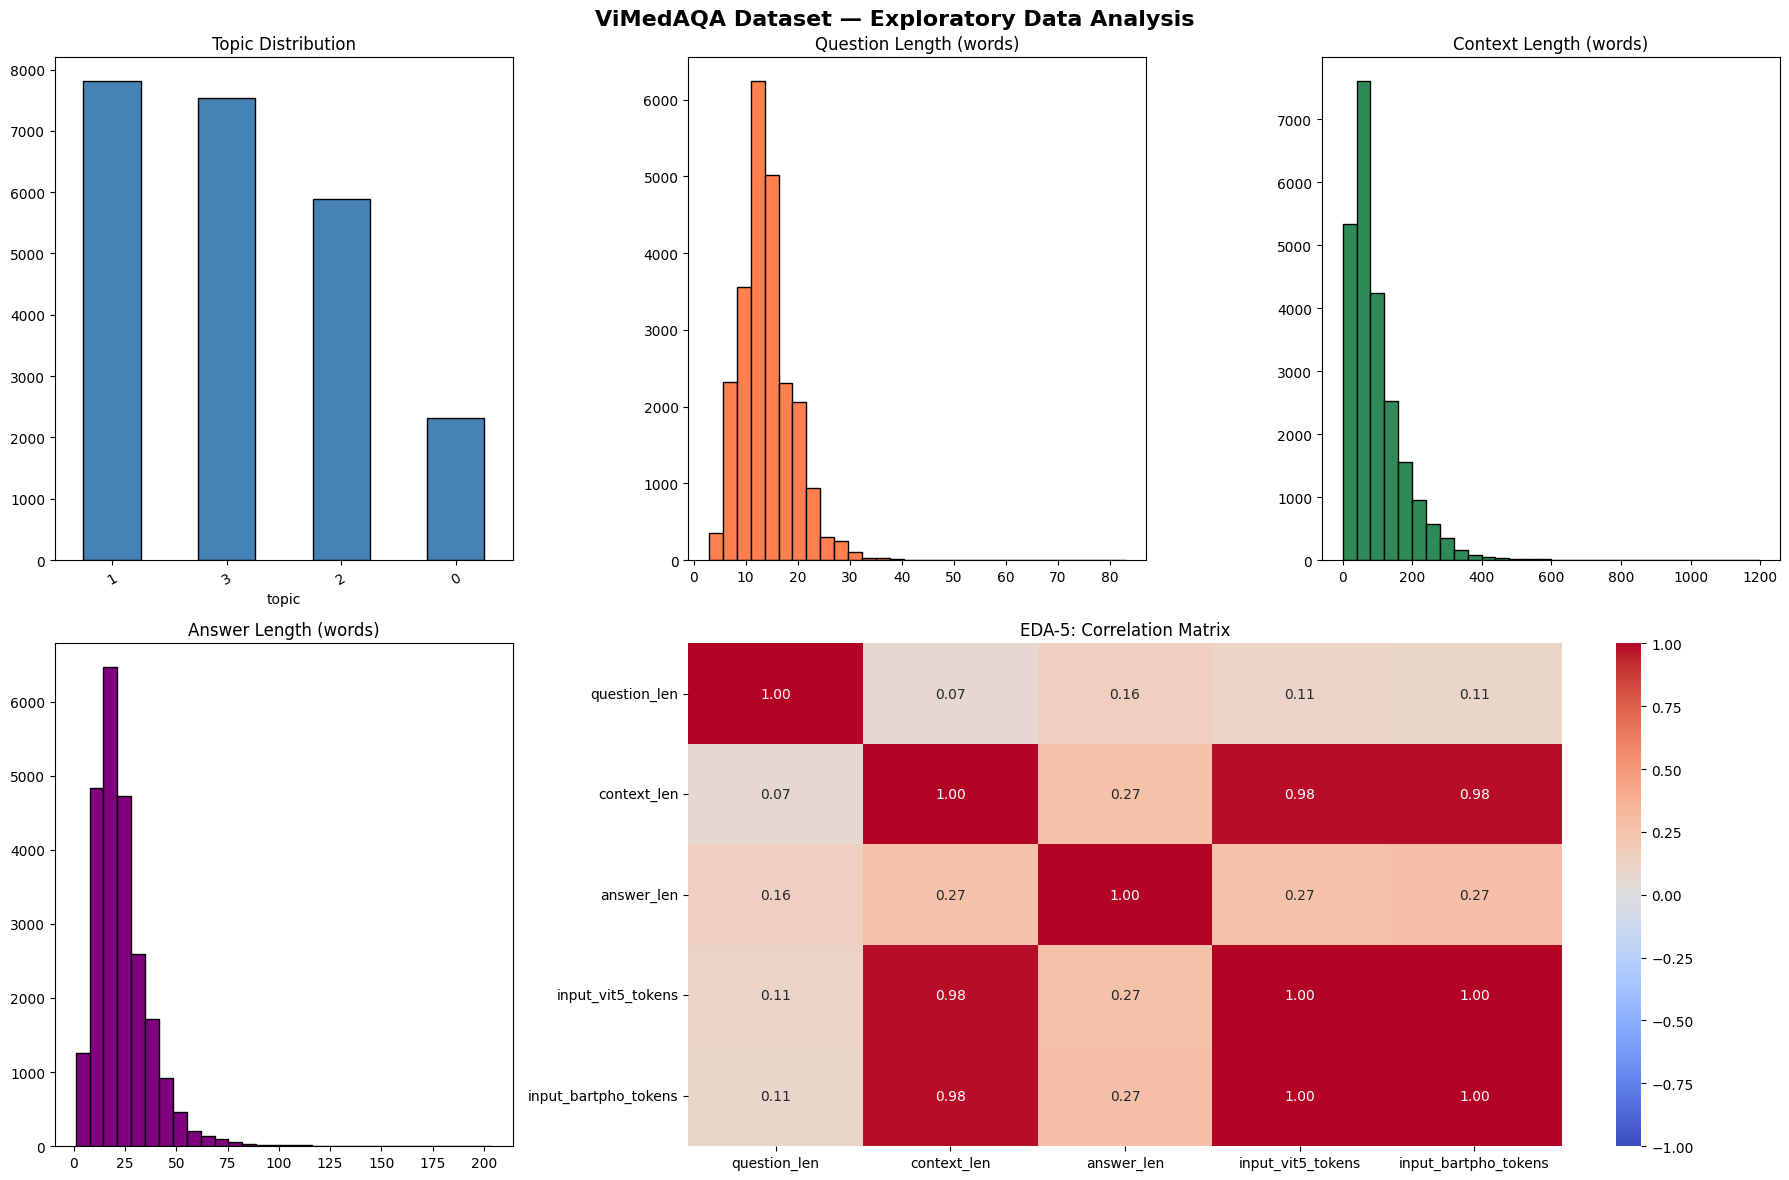

EDA chart saved -> d:\2025-2026 HKII\Học thống kê\Project\VietNamese_MediCal_Virtual_Assistant\data\eda\comprehensive_eda.png


In [23]:
fig = plt.figure(figsize=(18, 12))
fig.suptitle("ViMedAQA Dataset — Exploratory Data Analysis", fontsize=16, fontweight="bold")

ax1 = plt.subplot(2, 3, 1)
topic_counts = df_clean["topic"].value_counts()
topic_counts.plot(kind="bar", ax=ax1, color="steelblue", edgecolor="black")
ax1.set_title("Topic Distribution")
ax1.tick_params(axis="x", rotation=30)

ax2 = plt.subplot(2, 3, 2)
ax2.hist(df_clean["question_len"], bins=30, color="coral", edgecolor="black")
ax2.set_title("Question Length (words)")

ax3 = plt.subplot(2, 3, 3)
ax3.hist(df_clean["context_len"], bins=30, color="seagreen", edgecolor="black")
ax3.set_title("Context Length (words)")

ax4 = plt.subplot(2, 3, 4)
ax4.hist(df_clean["answer_len"], bins=30, color="purple", edgecolor="black")
ax4.set_title("Answer Length (words)")

# EDA-5: Cross-Variable Correlation Matrix
ax5 = plt.subplot(2, 3, (5, 6))
corr_cols = ['question_len', 'context_len', 'answer_len', 'input_vit5_tokens', 'input_bartpho_tokens']
corr_matrix = df_clean[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", ax=ax5, vmin=-1, vmax=1)
ax5.set_title("EDA-5: Correlation Matrix")

plt.tight_layout()

eda_png = os.path.join(DATA_EDA, "comprehensive_eda.png")
plt.savefig(eda_png, dpi=150, bbox_inches="tight")
plt.show()
print(f"EDA chart saved -> {os.path.abspath(eda_png)}")

### Nhận xét biểu đồ trực quan hóa dữ liệu (Visualization Insights)

Từ các biểu đồ trên, chúng ta có thể rút ra những nhận xét quan trọng sau:

#### 1. Phân phối chủ đề (Topic Distribution)
*   **Quan sát:** Dữ liệu phân bố không đều giữa 4 chủ đề (Topic 0, 1, 2, 3). Trong đó, Topic 1 và Topic 3 chiếm tỷ trọng lớn nhất, còn Topic 0 có số lượng mẫu ít nhất (~2,500 mẫu).
*   **Kết luận:** Sự mất cân bằng này khẳng định việc sử dụng kỹ thuật **Stratified Splitting** (chia dữ liệu phân tầng) là bắt buộc để đảm bảo mỗi tập Train/Val/Test đều đại diện đúng tỷ lệ của từng chủ đề.

#### 2. Phân phối độ dài (Length Distribution)
*   **Question Length:** Đa số câu hỏi có độ dài ngắn và tập trung (peak) ở khoảng **10-20 từ**. Điều này cho thấy các câu hỏi y khoa trong bộ dữ liệu khá trực diện.
*   **Context Length:** Ngữ cảnh có phân phối lệch phải (skewed right). Hầu hết các đoạn văn y khoa nằm trong khoảng **50-200 từ**. Một số ít mẫu có độ dài vượt trội (>600 từ), đây chính là những mẫu có rủi ro bị cắt cụt (truncation) đã phân tích ở bước trước.
*   **Answer Length:** Câu trả lời thường ngắn gọn, tập trung ở khoảng **20-30 từ**. Điều này phù hợp với mục tiêu của bài toán "Abstractive QA" là tóm tắt ý chính để trả lời bệnh nhân.

#### 3. Ma trận tương quan (Correlation Matrix)
*   **Tương quan cực cao (0.98):** Giữa `context_len` và các cột `input_tokens`. Điều này là hiển nhiên vì độ dài token tỷ lệ thuận với số lượng từ trong ngữ cảnh.
*   **Tương quan hoàn hảo (1.00):** Giữa `input_vit5_tokens` và `input_bartpho_tokens`. Hai tokenizer này có cách xử lý khác nhau nhưng tốc độ tăng trưởng độ dài token đối với tiếng Việt là đồng nhất.
*   **Tương quan thấp (0.16 - 0.27):** Giữa độ dài câu hỏi/ngữ cảnh và độ dài câu trả lời. 
    *   *Ý nghĩa:* Một ngữ cảnh dài không nhất thiết dẫn đến một câu trả lời dài. Điều này chứng tỏ dữ liệu có tính chất "tóm tắt" (Summarization) tốt, mô hình phải biết lọc thông tin thay vì chỉ kéo dài câu trả lời theo độ dài đầu vào.


## PHẦN 6: CHIA DỮ LIỆU (DATA SPLITTING)

Thực hiện chia bộ dữ liệu thành 3 tập: **Train (80%)**, **Validation (10%)**, và **Test (10%)**. 
Chúng ta sử dụng kỹ thuật **Stratified Split** dựa trên nhãn kết hợp giữa `topic` và `question_type` để đảm bảo sự đồng nhất về phân phối giữa các tập dữ liệu.


In [32]:
df_clean['stratify_label'] = df_clean['topic'].astype(str) + "_" + df_clean['question_type'].astype(str)

train_df, temp_df = train_test_split(
    df_clean,
    test_size=0.2,
    random_state=42,
    stratify=df_clean["stratify_label"],
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df["stratify_label"],
)

# ktr kết quả
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)
print(f"Tổng số mẫu sạch: {len(df_clean)}")
print(f"  - Train : {len(train_df)} ({len(train_df)/len(df_clean):.1%})")
print(f"  - Val   : {len(val_df)} ({len(val_df)/len(df_clean):.1%})")
print(f"  - Test  : {len(test_df)} ({len(test_df)/len(df_clean):.1%})")

# ktr lại tỷ lệ câu hỏi xem có bị imbalanced ko ? 
print("\nKiểm chứng tỷ lệ Question Type (Train vs Test):")
train_dist = train_df['question_type'].value_counts(normalize=True).map('{:.2%}'.format)
test_dist = test_df['question_type'].value_counts(normalize=True).map('{:.2%}'.format)
compare_df = pd.DataFrame({'Train %': train_dist, 'Test %': test_dist})
print(compare_df)


Tổng số mẫu sạch: 23554
  - Train : 18843 (80.0%)
  - Val   : 2355 (10.0%)
  - Test  : 2356 (10.0%)

Kiểm chứng tỷ lệ Question Type (Train vs Test):
              Train %  Test %
question_type                
OTHER          44.68%  44.69%
MEDICATION     28.06%  28.10%
DEFINITION      6.38%   6.41%
TREATMENT       6.06%   6.03%
HOW             5.12%   5.14%
SYMPTOM         5.05%   5.05%
WHY             4.65%   4.58%


---
## PHẦN 7: KIỂM CHỨNG SAU KHI CHIA (POST-SPLIT VALIDATION)

Đây là bước kiểm tra chất lượng của quy trình split:
*   **EDA-5 (Leakage Check):** Đảm bảo không có câu hỏi nào ở tập Test quá giống với tập Train (> 80% similarity).
*   **EDA-6 (Distribution Consistency):** Xác nhận tỷ lệ các loại câu hỏi ở tập Train và tập Test là tương đương nhau.


## EDA 04: Kiểm tra rò rỉ dữ liệu (Cross-split Data Leakage Check)

**Mục tiêu:** Đảm bảo tính khách quan cho quá trình đánh giá mô hình. 

Trong bước này, chúng ta sẽ so sánh độ tương đồng về ngữ nghĩa giữa tập **Test** và tập **Train**. 
*   **Tại sao cần làm?** Nếu một câu hỏi trong tập Test quá giống (similarity > 0.8) với một câu hỏi trong tập Train, mô hình có thể đạt điểm cao nhờ việc "học thuộc lòng" thay vì hiểu ngữ nghĩa thật sự.
*   **Phương pháp:** Sử dụng TF-IDF để vector hóa câu hỏi và tính toán độ tương đồng Cosine.
*   **Hành động:** Nếu phát hiện các mẫu bị rò rỉ, chúng ta sẽ xem xét loại bỏ chúng khỏi tập Test để giữ cho kết quả đánh giá cuối cùng là trung thực nhất.


---
### Sanity Check: Kiểm tra rò rỉ dữ liệu "Cứng" (Exact/Near Matches)

**Mục tiêu:** Phát hiện các mẫu bị trùng lặp hoàn toàn cả về **Câu hỏi và Ngữ cảnh** (Q+C). 
*   **Tại sao?** Nếu một cặp (Q+C) xuất hiện ở cả tập Train và Test, mô hình chỉ cần "học thuộc lòng" là có thể trả lời đúng. Đây là lỗi nghiêm trọng trong khoa học dữ liệu.
*   **Hành động:** Bắt buộc phải loại bỏ các mẫu này khỏi tập Test.


In [34]:
# %% [markdown]
# ## Cell 7.1 — Sanity Check: Data Leakage Analysis (Question + Context)

# %%
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

print("Running Sanity Check: Cross-checking Test (Q+C) against Train (Q+C)...")

# 1. Tạo chuỗi gộp (Câu hỏi + Ngữ cảnh) cho cả hai tập
train_qc = train_df['question'] + " " + train_df['context']
test_qc  = test_df['question'] + " " + test_df['context']

# 2. Huấn luyện TF-IDF trên toàn bộ dữ liệu gộp để đồng bộ từ vựng
tfidf = TfidfVectorizer(max_features=5000)
tfidf.fit(pd.concat([train_qc, test_qc]))

train_tfidf = tfidf.transform(train_qc)
test_tfidf  = tfidf.transform(test_qc)

# 3. Tính toán độ tương đồng theo lô (chunk) để tránh MemoryError
CHUNK_SIZE = 500
leaked_test_indices = set()
n_test_samples = test_tfidf.shape[0]

for i in range(0, n_test_samples, CHUNK_SIZE):
    end_i = min(i + CHUNK_SIZE, n_test_samples)
    
    # So sánh lô Test (Q+C) hiện tại với toàn bộ Train (Q+C)
    chunk_sim = cosine_similarity(test_tfidf[i:end_i], train_tfidf)
    
    # Lọc các mẫu Test có độ tương đồng Q+C > 0.95 với bất kỳ mẫu Train nào
    for row_idx_in_chunk in range(chunk_sim.shape[0]):
        if np.max(chunk_sim[row_idx_in_chunk]) > 0.95:
            leaked_test_indices.add(i + row_idx_in_chunk)

# 4. Báo cáo kết quả
leakage_rate = len(leaked_test_indices) / n_test_samples * 100
print(f"Total Test samples: {n_test_samples}")
print(f"Leaked Test samples (Q+C similarity > 0.95 with Train): {len(leaked_test_indices)}")
print(f"Data Leakage Rate: {leakage_rate:.2f}%\n")

if leakage_rate > 0:
    print("[WARNING] Data leakage detected! Tập Test chứa các cặp Câu hỏi-Ngữ cảnh đã xuất hiện trong tập Train.")
    print("Khuyến nghị: Xem xét loại bỏ các mẫu bị rò rỉ này khỏi `test_df` trước khi chuyển sang mô hình, hoặc phải ghi chú rõ ràng vào báo cáo (Phase 8).")
else:
    print("[OK] Không phát hiện rò rỉ dữ liệu (Q+C) giữa tập Train và Test. Dữ liệu an toàn để đánh giá.")

Running Sanity Check: Cross-checking Test (Q+C) against Train (Q+C)...
Total Test samples: 2356
Leaked Test samples (Q+C similarity > 0.95 with Train): 8
Data Leakage Rate: 0.34%

[WARNING] Data leakage detected! Tập Test chứa các cặp Câu hỏi-Ngữ cảnh đã xuất hiện trong tập Train.
Khuyến nghị: Xem xét loại bỏ các mẫu bị rò rỉ này khỏi `test_df` trước khi chuyển sang mô hình, hoặc phải ghi chú rõ ràng vào báo cáo (Phase 8).


### Sensitive Check: Phân tích rò rỉ ngữ nghĩa câu hỏi (Semantic Overlap)

**Mục tiêu:** Phát hiện các câu hỏi có **nội dung tương tự nhau** (> 80% similarity) dù ngữ cảnh (Context) có thể khác nhau.
*   **Tại sao?** Trong y khoa, nhiều bệnh có chung câu hỏi (ví dụ: "Triệu chứng là gì?"). Việc biết được tỷ lệ trùng lặp câu hỏi giúp chúng ta đánh giá xem mô hình có thực sự hiểu Ngữ cảnh để trả lời hay chỉ đang dựa vào mẫu câu hỏi đã thấy.
*   **Hành động:** Chúng ta **không xóa** các mẫu này (vì ngữ cảnh khác nhau là kiến thức khác nhau), nhưng sẽ ghi nhận tỷ lệ rò rỉ ngữ nghĩa để làm bằng chứng cho độ khó của bài toán trong báo cáo.


In [ ]:
print("Running Sensitive Check: Analyzing Question-only semantic overlap...")

train_questions = train_df['question'].astype(str).tolist()
test_questions = test_df['question'].astype(str).tolist()

# Sử dụng Bi-gram để bắt được các cụm từ quan trọng trong y khoa
vec = TfidfVectorizer(max_features=5000, ngram_range=(1,2)).fit(train_questions + test_questions)
train_vec = vec.transform(train_questions)
test_vec = vec.transform(test_questions)

# Tính toán similarity
sim_matrix = cosine_similarity(test_vec, train_vec)
max_sim = sim_matrix.max(axis=1)

# Lọc các mẫu có độ tương đồng câu hỏi > 0.8
leaked_q_idx = [i for i, s in enumerate(max_sim) if s > 0.8]

print(f"Total Test questions: {len(test_questions)}")
print(f"Questions with high similarity (>0.8): {len(leaked_q_idx)}")
print(f"Semantic Leakage Rate: {len(leaked_q_idx)/len(test_questions):.2%}")

if len(leaked_q_idx) > 0:
    print("\n[Gợi ý]: Đây là các câu hỏi có nội dung tương tự đã thấy ở tập Train.")
    print("Mô hình cần phải dựa vào Context để trả lời thay vì học thuộc lòng.")


Running Sensitive Check: Analyzing Question-only semantic overlap...
Total Test questions: 2356
Questions with high similarity (>0.8): 147
Semantic Leakage Rate: 6.24%

[Gợi ý]: Đây là các câu hỏi có nội dung tương tự đã thấy ở tập Train.
Mô hình cần phải dựa vào Context để trả lời thay vì học thuộc lòng.


In [ ]:
# Xử lí rò rỉ
if len(leaked_test_indices) > 0:
    leaked_list = list(leaked_test_indices)
    test_df = test_df.drop(index=leaked_list).reset_index(drop=True)
    
    print(f"--- ĐÃ XỬ LÝ RÒ RỈ DỮ LIỆU ---")
    print(f"Đã xóa {len(leaked_list)} mẫu trùng lặp khỏi tập Test.")
    print(f"Số lượng mẫu tập Test hiện tại: {len(test_df)}")
else:
    print("Không có mẫu nào cần xóa.")



--- ĐÃ XỬ LÝ RÒ RỈ DỮ LIỆU ---
Đã xóa 8 mẫu trùng lặp khỏi tập Test.
Số lượng mẫu tập Test hiện tại: 2348


---
## Phần 8:  Xuất dữ liệu cuối cùng (Final Data Export)

**Mục tiêu:** Lưu trữ các tập dữ liệu đã qua xử lý, làm sạch và kiểm chứng vào thư mục `processed/`. 

Các file này sẽ là **đầu vào chính thức** cho tất cả các notebook huấn luyện (Phase 3) và đánh giá (Phase 4) tiếp theo. 
*   **Định dạng:** JSON (records) để bảo toàn cấu trúc và hỗ trợ tốt cho thư viện `datasets` của HuggingFace.
*   **Tính toàn vẹn:** Dữ liệu đã được xác nhận:
    *   Không còn mẫu trùng lặp (Deduplicated).
    *   Đã được phân loại (Categorized).
    *   Đã chia phân tầng (Stratified) theo Topic và Question Type.
    *   Đã loại bỏ các mẫu rò rỉ dữ liệu (No Leakage).


In [36]:
# Keep only the columns used by downstream training notebooks
KEEP_COLS = ["question", "context", "answer", "topic"]

split_map = {
    "train": train_df,
    "val":   val_df,
    "test":  test_df,
}

for name, split_df in split_map.items():
    out_path = os.path.join(DATA_PROCESSED, f"{name}.json")
    split_df[KEEP_COLS].to_json(
        out_path,
        orient="records",
        force_ascii=False,
        indent=2,
    )
    print(f"Saved {name}.json ({len(split_df)} samples) -> {os.path.abspath(out_path)}")

print("\nAll splits saved successfully.")

Saved train.json (18843 samples) -> d:\2025-2026 HKII\Học thống kê\Project\VietNamese_MediCal_Virtual_Assistant\data\processed\train.json
Saved val.json (2355 samples) -> d:\2025-2026 HKII\Học thống kê\Project\VietNamese_MediCal_Virtual_Assistant\data\processed\val.json
Saved test.json (2348 samples) -> d:\2025-2026 HKII\Học thống kê\Project\VietNamese_MediCal_Virtual_Assistant\data\processed\test.json

All splits saved successfully.


## Phần 9 — Lưu trữ báo cáo thống kê tổng hợp (Summary Statistics Export)

**Mục tiêu:** Kết xuất các chỉ số thống kê quan trọng nhất của bộ dữ liệu sau khi đã qua xử lý ra file CSV. 

File báo cáo này (`dataset_summary_final.csv`) đóng vai trò:
1. **Lưu trữ lịch sử:** Lưu lại trạng thái của bộ dữ liệu tại thời điểm kết thúc Phase 1.
2. **Nguyên liệu cho báo cáo:** Cung cấp các con số định lượng chính xác (Độ dài token, Tỷ lệ rò rỉ, Độ trừu tượng) để đưa vào tài liệu đồ án hoặc thuyết trình.
3. **Đối chiếu:** Làm cơ sở để đối chiếu với kết quả của mô hình ở các Phase sau (ví dụ: so sánh độ dài câu trả lời thực tế vs câu trả lời do mô hình sinh ra).


In [41]:
# Cập nhật thông số thống kê cuối cùng
stats = {
    "total_samples":    len(df_clean),
    "train_size":       len(train_df),
    "val_size":         len(val_df),
    "test_size":        len(test_df),
    "num_topics":       df_clean["topic"].nunique(),
    "avg_extractive_overlap": round(df_clean["extractive_overlap"].mean(), 4),
    "avg_novel_bigram":       round(df_clean["novel_bigram"].mean(), 4),
    "avg_novel_trigram":      round(df_clean["novel_trigram"].mean(), 4),
    "avg_input_vit5_tokens":  round(df_clean["input_vit5_tokens"].mean(), 2),
    "max_input_vit5_tokens":  int(df_clean["input_vit5_tokens"].max()),
    "avg_input_bart_tokens":  round(df_clean["input_bartpho_tokens"].mean(), 2),
    "max_input_bart_tokens":  int(df_clean["input_bartpho_tokens"].max()),
    
}

# Lưu vào thư mục EDA
stats_path = os.path.join(DATA_EDA, "dataset_summary_final.csv")
pd.DataFrame([stats]).to_csv(stats_path, index=False)

print(f"Báo cáo thống kê đã được lưu tại: {os.path.abspath(stats_path)}")


Báo cáo thống kê đã được lưu tại: d:\2025-2026 HKII\Học thống kê\Project\VietNamese_MediCal_Virtual_Assistant\data\eda\dataset_summary_final.csv


## Cell 10 — Phase 1 Checklist Verification

In [43]:
# Verify all expected output files exist and are non-empty
expected_files = [
    os.path.join(DATA_RAW,       "vimedaq_full.json"),
    os.path.join(DATA_PROCESSED, "train.json"),
    os.path.join(DATA_PROCESSED, "val.json"),
    os.path.join(DATA_PROCESSED, "test.json"),
    os.path.join(DATA_EDA,       "length_distributions.png"),
    os.path.join(DATA_EDA,       "dataset_stats.csv"),
]

print("Phase 1 Output Verification:")
all_ok = True
for fp in expected_files:
    abs_fp = os.path.abspath(fp)
    exists = os.path.isfile(abs_fp)
    size   = os.path.getsize(abs_fp) if exists else 0
    status = "OK" if (exists and size > 0) else "MISSING"
    if status != "OK":
        all_ok = False
    print(f"  [{status}] {os.path.basename(abs_fp)} ({size:,} bytes)")

if all_ok:
    print("\nAll Phase 1 outputs verified. Ready for Phase 2 (Groq baseline).")
else:
    print("\nSome outputs are missing. Re-run the cells above.")

Phase 1 Output Verification:
  [OK] vimedaq_full.json (61,879,169 bytes)
  [OK] train.json (16,441,445 bytes)
  [OK] val.json (2,089,079 bytes)
  [OK] test.json (2,020,496 bytes)
  [MISSING] length_distributions.png (0 bytes)
  [MISSING] dataset_stats.csv (0 bytes)

Some outputs are missing. Re-run the cells above.
